## Wetness diagnostics (bias / wet fraction / false positives)

This section recomputes diagnostics directly from raw predictions to test the "over-wetting" hypothesis.
Update the paths below to your test PKLs and checkpoint folders before running.


In [6]:
import os, sys, math
import torch, dgl
import numpy as np
import pandas as pd

ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.append(ROOT)

from python.create_dgl_dataset import TelemacDataset
from python.CustomMeshGraphNet import MeshGraphNet
from modulus.launch.utils import load_checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [12]:
# =====================
# Parametres utilisateur (a adapter)
# =====================

DATA_DIR = "/work/m24046/m24046mrcr/paper/Experience2/Multimesh_8_32.bin"
DYNAMIC_DIR = [
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_1_peak_2600_Group_1_peak_2600_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_2_peak_1000_Group_2_peak_1000_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_2_peak_1200_Group_2_peak_1200_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_2_peak_1600_Group_2_peak_1600_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_4_peak_2000_Group_4_peak_2000_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_1_peak_1200_Group_1_peak_1200_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_1_peak_2400_Group_1_peak_2400_0_0-80_interpolated.pkl",
    "/work/m24046/m24046mrcr/results_data_30min_35_70_maillagex8/Group_3_peak_3400_Group_3_peak_3400_0_0-80_interpolated.pkl",
]

HORIZONS_STEPS = list(horizons) if 'horizons' in globals() else [12, 24]
MAX_SEQUENCES = 205
THRESHOLD_M = 0.05
OVERLAP = 1
MASK_BOUNDARY = True  # True = on exclut les BC des stats wet/bias

# Parametres modele (coherents avec l'entrainement)
NUM_INPUT_FEATURES = 9
NUM_EDGE_FEATURES = 3
NUM_OUTPUT_FEATURES = 3
MP_LAYERS = 10
DO_CONCAT_TRICK = True
NUM_PROCESSOR_CHECKPOINT_SEGMENTS = 0

# Checkpoints a comparer
exp_nodice_name = exp_nodice if 'exp_nodice' in globals() else 'nodice'
exp_dice_name = exp_dice if 'exp_dice' in globals() else 'dice'

EXPERIMENTS = {
    exp_nodice_name: {
        'ckpt_dir': '/work/m24046/m24046mrcr/paper/Experience3/Seed0/',
        'epochs': [600, 650, 700, 750, 800,850,900],
    },
    exp_dice_name: {
        'ckpt_dir': '/work/m24046/m24046mrcr/paper/Experience5_1/Seed0/',
        'epochs': [600, 650, 700, 750, 800,850,900],
    },
}


In [13]:
# =====================
# Fonctions utilitaires
# =====================
def build_model():
    return MeshGraphNet(
        NUM_INPUT_FEATURES,
        NUM_EDGE_FEATURES,
        NUM_OUTPUT_FEATURES,
        processor_size=MP_LAYERS,
        hidden_dim_processor=64,
        hidden_dim_node_encoder=64,
        hidden_dim_edge_encoder=64,
        hidden_dim_node_decoder=64,
        do_concat_trick=DO_CONCAT_TRICK,
        num_processor_checkpoint_segments=NUM_PROCESSOR_CHECKPOINT_SEGMENTS,
    )

def load_model_checkpoint(model, ckpt_dir, epoch):
    load_checkpoint(ckpt_dir, models=model, device=device, epoch=epoch)
    model.to(device)
    model.eval()
    return model

def build_dataset(sequence_length, overlap, ckpt_dir, split="test"):
    return TelemacDataset(
        name=f"eval_{split}",
        data_dir=DATA_DIR,
        dynamic_data_files=DYNAMIC_DIR,
        split=split,
        ckpt_path=ckpt_dir,
        normalize=True,
        sequence_length=sequence_length,
        overlap=overlap,
    )

def _denorm(xn, mean, std):
    return xn * std + mean

def _renorm(x, mean, std):
    return (x - mean) / (std + 1e-12)

def evaluate_model_wetness(model, ds, horizons_steps, max_sequences=10, threshold=0.05, mask_boundary=True):
    stats = ds.node_stats
    dyn_start = ds.base_graph.ndata['static'].shape[1]
    mx = torch.tensor([stats['h'].item(), stats['u'].item(), stats['v'].item()], device=device)
    sx = torch.tensor([stats['h_std'].item(), stats['u_std'].item(), stats['v_std'].item()], device=device)
    dy_mean = torch.tensor([stats['delta_h'].item(), stats['delta_u'].item(), stats['delta_v'].item()], device=device)
    dy_std  = torch.tensor([stats['delta_h_std'].item(), stats['delta_u_std'].item(), stats['delta_v_std'].item()], device=device)

    agg = {h: {
        'count': 0,
        'bias_sum': 0.0,
        'wet_pred_sum': 0,
        'wet_gt_sum': 0,
        'fp_sum': 0,
        'fn_sum': 0,
    } for h in horizons_steps}

    nseq = min(max_sequences, len(ds))
    max_h = max(horizons_steps)

    for idx in range(nseq):
        graphs = ds[idx]
        if len(graphs) <= max_h:
            continue
        g = graphs[0].to(device)
        static_part = g.ndata['x'][:, :dyn_start]
        xn_t = g.ndata['x'][:, dyn_start:dyn_start+3]

        onehot = static_part[:, :4]
        q_mask = (onehot == torch.tensor([0,0,1,0], device=device)).all(dim=1)
        h_mask = (onehot == torch.tensor([0,1,0,0], device=device)).all(dim=1)
        interior_mask = ~(q_mask | h_mask) if mask_boundary else torch.ones_like(q_mask)

        for t in range(max_h):
            with torch.no_grad():
                y_pred_n = model(g.ndata['x'], g.edata['x'], g)
            x_t = _denorm(xn_t, mx, sx)
            y_pred = _denorm(y_pred_n, dy_mean, dy_std)
            x_t1 = x_t + y_pred

            x_gt_n = graphs[t+1].ndata['x'][:, dyn_start:dyn_start+3].to(device)
            x_gt = _denorm(x_gt_n, mx, sx)

            # Conditions limites
            x_t1[q_mask] = x_gt[q_mask]
            x_t1[h_mask, 0:1] = x_gt[h_mask, 0:1]

            step = t + 1
            if step in horizons_steps:
                h_pred = x_t1[:, 0][interior_mask]
                h_gt = x_gt[:, 0][interior_mask]
                if h_pred.numel() == 0:
                    continue

                h_pred_np = h_pred.detach().cpu().numpy()
                h_gt_np = h_gt.detach().cpu().numpy()

                pred_wet = h_pred_np >= threshold
                gt_wet = h_gt_np >= threshold

                n = h_pred_np.size
                agg[step]['count'] += n
                agg[step]['bias_sum'] += float((h_pred_np - h_gt_np).sum())
                agg[step]['wet_pred_sum'] += int(pred_wet.sum())
                agg[step]['wet_gt_sum'] += int(gt_wet.sum())
                agg[step]['fp_sum'] += int(np.logical_and(pred_wet, ~gt_wet).sum())
                agg[step]['fn_sum'] += int(np.logical_and(~pred_wet, gt_wet).sum())

            # reinjection
            xn_t = _renorm(x_t1, mx, sx)
            g = g.clone()
            g.ndata['x'] = torch.cat([static_part, xn_t], dim=1)

    summary = {}
    for h in horizons_steps:
        count = agg[h]['count']
        if count == 0:
            continue
        wet_pred = agg[h]['wet_pred_sum'] / count
        wet_gt = agg[h]['wet_gt_sum'] / count
        summary[h] = {
            'bias_mean': agg[h]['bias_sum'] / count,
            'wet_frac_pred': wet_pred,
            'wet_frac_gt': wet_gt,
            'wet_frac_delta': wet_pred - wet_gt,
            'false_pos_rate': agg[h]['fp_sum'] / count,
            'false_neg_rate': agg[h]['fn_sum'] / count,
        }
    return summary

def run_wet_eval(experiments):
    rows = []
    seq_len = max(HORIZONS_STEPS) + 1
    for exp_name, cfg in experiments.items():
        ckpt_dir = cfg['ckpt_dir']
        epochs = cfg['epochs']
        ds = build_dataset(sequence_length=seq_len, overlap=OVERLAP, ckpt_dir=ckpt_dir)
        for ep in epochs:
            model = build_model()
            load_model_checkpoint(model, ckpt_dir, epoch=ep)
            summary = evaluate_model_wetness(
                model,
                ds,
                HORIZONS_STEPS,
                max_sequences=MAX_SEQUENCES,
                threshold=THRESHOLD_M,
                mask_boundary=MASK_BOUNDARY,
            )
            for h, vals in summary.items():
                rows.append({
                    'exp': exp_name,
                    'epoch': ep,
                    'horizon_steps': h,
                    **vals,
                })
    return pd.DataFrame(rows)


In [14]:
wet_df = run_wet_eval(EXPERIMENTS)
wet_df.sort_values(["exp", "horizon_steps", "epoch"]).head()


[11:36:38 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience3/Seed0/MeshGraphNet.0.600.mdlus to device cuda


Loading normalization statistics...


[11:36:39 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience3/Seed0/checkpoint.0.600.pt to device cuda
[11:36:42 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience3/Seed0/MeshGraphNet.0.650.mdlus to device cuda
[11:36:42 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience3/Seed0/checkpoint.0.650.pt to device cuda
[11:36:45 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience3/Seed0/MeshGraphNet.0.700.mdlus to device cuda
[11:36:45 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience3/Seed0/checkpoint.0.700.pt to device cuda
[11:36:48 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience3/Seed0/MeshGraphNet.0.750.mdlus to device cuda
[11:36:48 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience3/Seed0/checkpoint.0.750.pt to device cuda
[11:3

Loading normalization statistics...


[11:37:00 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience5_1/Seed0/checkpoint.0.600.pt to device cuda
[11:37:03 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience5_1/Seed0/MeshGraphNet.0.650.mdlus to device cuda
[11:37:03 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience5_1/Seed0/checkpoint.0.650.pt to device cuda
[11:37:06 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience5_1/Seed0/MeshGraphNet.0.700.mdlus to device cuda
[11:37:06 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience5_1/Seed0/checkpoint.0.700.pt to device cuda
[11:37:09 - checkpoint - INFO] Loaded model state dictionary /work/m24046/m24046mrcr/paper/Experience5_1/Seed0/MeshGraphNet.0.750.mdlus to device cuda
[11:37:09 - checkpoint - INFO] Loaded checkpoint file /work/m24046/m24046mrcr/paper/Experience5_1/Seed0/checkpoint.0.750.pt to dev

,exp,epoch,horizon_steps,bias_mean,wet_frac_pred,wet_frac_gt,wet_frac_delta,false_pos_rate,false_neg_rate
14,dice,600,12,-0.541317,0.153168,0.327376,-0.174208,0.004955,0.179163
16,dice,650,12,-0.431658,0.165002,0.327376,-0.162374,0.005280,0.167654
18,dice,700,12,-0.418711,0.167963,0.327376,-0.159413,0.005875,0.165288
20,dice,750,12,-0.395101,0.168682,0.327376,-0.158695,0.005426,0.164121
22,dice,800,12,-0.371215,0.178019,0.327376,-0.149357,0.008356,0.157713


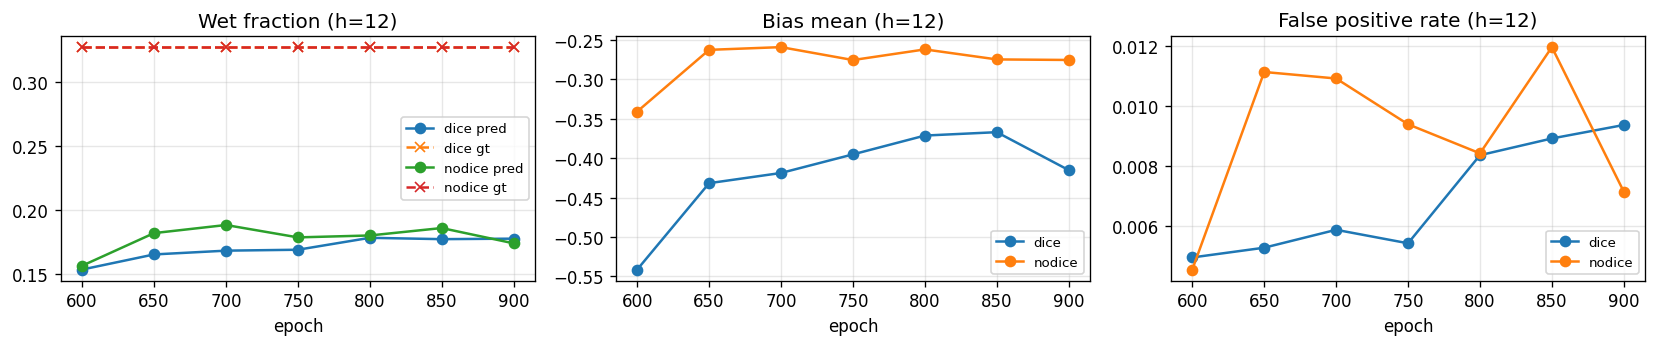

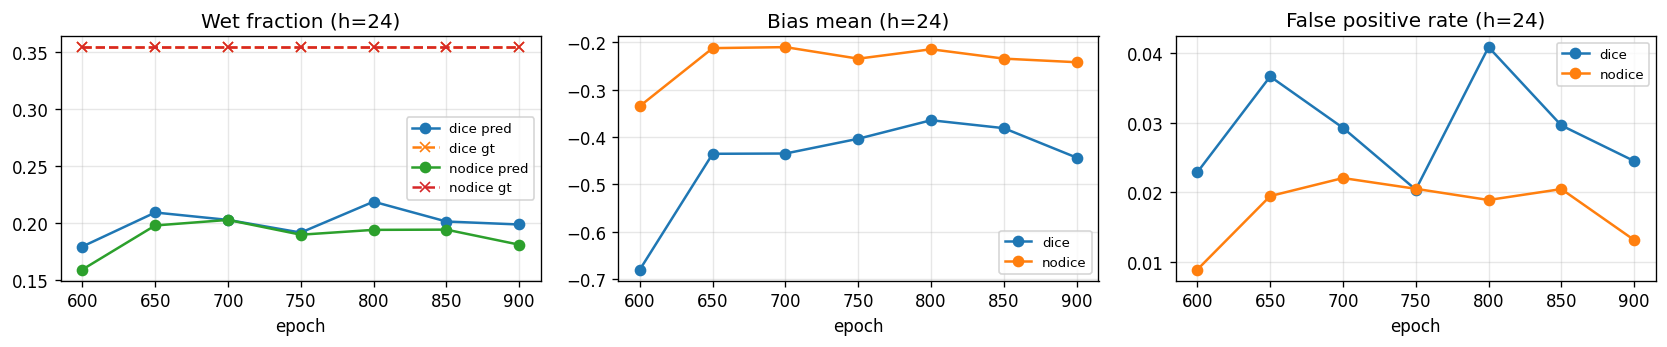

In [15]:
def plot_wet_metrics(df, horizons_steps):
    for h in horizons_steps:
        sub = df[df["horizon_steps"].eq(h)]
        if sub.empty:
            continue
        fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharex=True)
        for exp_name, g in sub.groupby("exp"):
            g = g.sort_values("epoch")
            axes[0].plot(g["epoch"], g["wet_frac_pred"], marker="o", label=f"{exp_name} pred")
            axes[0].plot(g["epoch"], g["wet_frac_gt"], marker="x", linestyle="--", label=f"{exp_name} gt")
            axes[1].plot(g["epoch"], g["bias_mean"], marker="o", label=exp_name)
            axes[2].plot(g["epoch"], g["false_pos_rate"], marker="o", label=exp_name)

        axes[0].set_title(f"Wet fraction (h={h})")
        axes[1].set_title(f"Bias mean (h={h})")
        axes[2].set_title(f"False positive rate (h={h})")

        for ax in axes:
            ax.grid(True, alpha=0.3)
            ax.set_xlabel("epoch")
        axes[0].legend(loc="best", fontsize=8)
        axes[1].legend(loc="best", fontsize=8)
        axes[2].legend(loc="best", fontsize=8)
        plt.tight_layout()
        plt.show()

plot_wet_metrics(wet_df, HORIZONS_STEPS)


In [16]:
wet_df

,exp,epoch,horizon_steps,bias_mean,wet_frac_pred,wet_frac_gt,wet_frac_delta,false_pos_rate,false_neg_rate
0,nodice,600,12,-0.340709,0.156151,0.327376,-0.171225,0.004553,0.175778
1,nodice,600,24,-0.334665,0.158957,0.354137,-0.195180,0.008928,0.204108
2,nodice,650,12,-0.262385,0.181706,0.327376,-0.145670,0.011123,0.156793
3,nodice,650,24,-0.212226,0.197630,0.354137,-0.156507,0.019487,0.175994
4,nodice,700,12,-0.258931,0.188053,0.327376,-0.139323,0.010907,0.150230
5,nodice,700,24,-0.210094,0.202508,0.354137,-0.151629,0.022077,0.173706
6,nodice,750,12,-0.275346,0.178359,0.327376,-0.149017,0.009384,0.158401
7,nodice,750,24,-0.234509,0.189529,0.354137,-0.164608,0.020531,0.185139
8,nodice,800,12,-0.261833,0.179851,0.327376,-0.147525,0.008418,0.155943
9,nodice,800,24,-0.214614,0.193781,0.354137,-0.160357,0.018923,0.179279
